## Visualizing Named Entities with Spark NLP

### Creating visualizations for analysis and reporting using Spark NLP and Spark NLP display.

By definition, NLP visualizer is a tool or library that allows you to create visual representations of Natural Language Processing (NLP) models and data.

NLP visualizers can be used to visualize the outputs of NLP models, such as Named Entity Recognition (NER), relations between entities, dependencies and more. They are widely used by data scientists, business analysts, and researchers to gain insights from text data and communicate their findings to others. They can also be used to communicate the results of NLP models to non-technical stakeholders, such as business users or customers.

Spark NLP Display is an open-source python library for visualizing the annotations, developed and maintained by John Snow Labs. It currently offers out-of-the-box support for the following types of annotations:

- Dependency Parser
- Named Entity Resolution (NER)
- Entity Resolution
- Relation Extraction
- Assertion Status

In this post, you will learn how to use Spark NLP Named Entity Resolution (NER) Visualizer. There is already a John Snow Labs post for the Dependency Parser. For the last 3 visualizers, licensed models are required for producing the entities and a key will be needed to run the initial models —those visualizers will be discussed in a future article.

The ability to quickly visualize the entities/relations/assertion status, etc. generated using Spark NLP is a very useful feature for speeding up the development process as well as for understanding the obtained results. Getting all of this in a one liner is extremely convenient, especially when running Jupyter notebooks which offers full support for html visualizations.

In this post, you will learn how to use NerVisualizer of Spark NLP to visualize named entities.

Let us start with a short Spark NLP introduction and then discuss the details of the visualizing named entities with some solid results.

Reference: https://medium.com/john-snow-labs/visualizing-named-entities-with-spark-nlp-eff04fd60b8c

### Introduction to Spark NLP
Spark NLP is an open-source library maintained by [John Snow Labs](https://www.johnsnowlabs.com/). It is built on top of Apache Spark and Spark ML and provides simple, performant & accurate NLP annotations for machine learning pipelines that can scale easily in a distributed environment.

Since its first release in July 2017, Spark NLP has grown in a full NLP tool, providing:

- A single unified solution for all your NLP needs
- Transfer learning and implementing the latest and greatest SOTA algorithms and models in NLP research
- The most widely used NLP library in industry (5 years in a row)
- The most scalable, accurate and fastest library in NLP history

Spark NLP comes with 17,800+ pretrained pipelines and models in more than 250+ languages. It supports most of the NLP tasks and provides modules that can be used seamlessly in a cluster.

Spark NLP processes the data using Pipelines, structure that contains all the steps to be run on the input data:

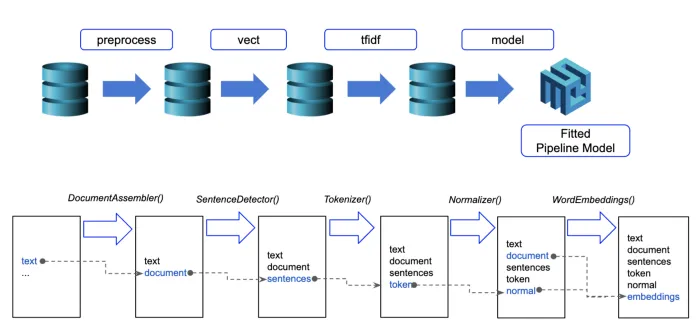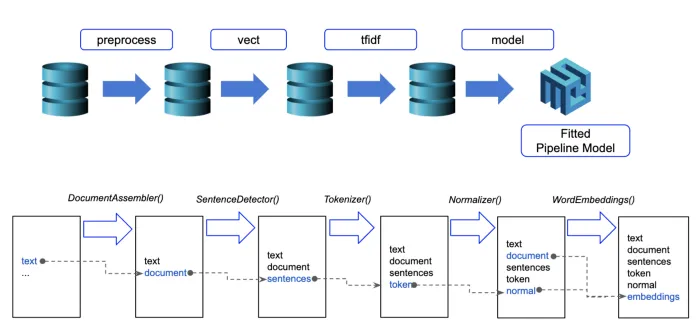

Each step contains an [annotator](https://nlp.johnsnowlabs.com/docs/en/concepts#annotators) that performs a specific task such as tokenization, normalization, and dependency parsing. Each annotator has input(s) [annotation](https://nlp.johnsnowlabs.com/docs/en/concepts#annotation)(s) and outputs new annotation.

An annotator in Spark NLP is a component that performs a specific NLP task on a text document and adds annotations to it. An annotator takes an input text document and produces an output document with additional metadata, which can be used for further processing or analysis. For example, a named entity recognizer annotator might identify and tag entities such as people, organizations, and locations in a text document, while a sentiment analysis annotator might classify the sentiment of the text as positive, negative, or neutral.

#### Setup
To install Spark NLP in Python, simply use your favorite package manager (conda, pip, etc.). 

For example:

In [1]:
#!pip install spark-nlp
#!pip install pyspark
#!pip install spark-nlp-display

For other installation options for different environments and machines, please check the [official documentation](https://nlp.johnsnowlabs.com/docs/en/install).

Then, simply import the library and start a Spark session:

In [2]:
import sparknlp

# Start Spark Session
spark = sparknlp.start()

### NER Visualizer

The goal of NER is to automatically detect and classify named entities in a given text document. This involves identifying the relevant words or phrases in a sentence that refer to named entities, and then assigning them to predefined categories such as person names, organization names, location names, dates, and more.

One common visualization technique for text annotations is to highlight or color-code the different types of annotations in the text. For example, in named entity recognition, proper nouns such as names of people, organizations, and locations are annotated. These can be highlighted in a specific color to help the user quickly identify them in the text.

```NerVisualizer``` highlights the named entities that are identified by Spark NLP and also displays their labels as decorations on top of the analyzed text. The colors assigned to the predicted labels can be configured to fit the particular needs of the application.

Let’s work on the following sample text to observe the capabilities of the Spark NLP ```NerVisualizer```.

In [3]:
example = [
"""One of the most prominent centers of the Renaissance was Florence, Italy, 
which produced many of the era's most influential painters. 
Among these was Sandro Botticelli, whose masterpieces include 
"The Birth of Venus" and "Primavera," both of which feature mythological 
themes and strikingly beautiful figures. Another great Renaissance painter 
from Florence was Michelangelo, known for his stunning frescoes 
on the ceiling of the Sistine Chapel, as well as his sculptures such as 
the "David" and "Pieta."""
]

#### Using a pretrained Pipeline — Recognize Entities DL Pipeline
```recognize_entities_dl``` is a [pretrained pipeline](https://nlp.johnsnowlabs.com/2021/03/23/recognize_entities_dl_en.html) that can be used to process text with a simple pipeline that performs basic processing steps and recognizes entities.

A pretrained pipeline in Spark NLP is a pre-built set of machine learning models and tools for performing NLP tasks. It is designed to provide a quick and easy way to get started with NLP, without requiring extensive expertise in machine learning or NLP.

In [4]:
# Import the required modules and libraries
from sparknlp.pretrained import PretrainedPipeline

# Define a pipeline
pipeline = PretrainedPipeline('recognize_entities_dl', lang='en')

recognize_entities_dl download started this may take some time.
Approx size to download 159 MB
[OK!]


#### Let’s get predictions from the pretrained pipeline.

In [5]:
ppres = pipeline.fullAnnotate(example)[0]

#### Now, we can visualize the results, plus we saved the results as an html file.

In [6]:
# First import NerVisualizer
from sparknlp_display import NerVisualizer

# Display the results
visualiser = NerVisualizer()

visualiser.display(ppres, label_col='entities', document_col='document', save_path=f"display_recognize_entities.html")

#### We also have the option to change the color of an entity, by defining the color code. Here, we defined the color codes for the PER and LOC entities.

In [7]:
# Define the color codes for certain entities
visualiser.set_label_colors({'LOC':'#008080', 'PER':'#800080'})

visualiser.display(ppres, label_col='entities')

#### We have the option to filter entities; in the following code, we filtered and opted to only display the entities labelled as “PER”.

In [8]:
# Filter the entities

visualiser.display(ppres, label_col='entities', document_col='document',
                   labels=['PER'])

print()
print ('color code for label "PER": ' + visualiser.get_label_color('PER'))



color code for label "PER": #800080


#### Using a pretrained NER Model — ner_dl
In this case, instead of using a predefined pipeline, we will use a pretrained model from John Snow Labs Models Hub. The Spark NLP library includes several pretrained NER models, which are trained on large amounts of text data and are ready to use out of the box.

```ner_dl``` is an NER model, meaning it annotates text to find features like the names of people, places, and organizations.

```ner_dl``` model is trained with GloVe 100D word embeddings, so the same embeddings should be used in the pipeline.

Let us use another text now:

In [9]:
example = [
"""Leonardo da Vinci was one of the most renowned polymaths in human history. 
Born in Vinci, Italy in 1452, he is best known for his masterful works of art. 
Throughout his life, Leonardo da Vinci lived and worked in various cities 
in Italy, including Florence, Milan, and Rome. He began his artistic career 
as an apprentice to Andrea del Verrocchio in Florence, where he honed 
his skills in painting, sculpture, and metalworking. Leonardo da Vinci 
died in Amboise, France in 1519, but his legacy has continued to 
inspire artists, scientists, and inventors for centuries."""
]

#### Spark NLP has the pipeline approach and the pipeline will include the necessary stages for extracting the entities from the text.

In [10]:
# Import the required modules and classes
from sparknlp.base import DocumentAssembler, Pipeline, LightPipeline
from sparknlp.annotator import (
    Tokenizer,
    WordEmbeddingsModel,
    NerDLModel,
    NerConverter
)
import pyspark.sql.functions as F

# Step 1: Transforms raw texts to `document` annotation
documentAssembler = DocumentAssembler()\
    .setInputCol("text")\
    .setOutputCol("document")

# Step 2: Tokenization
tokenizer = Tokenizer() \
    .setInputCols(["document"]) \
    .setOutputCol("token")

# Step 3: Get the embeddings using glove_100d
embeddings = WordEmbeddingsModel.pretrained('glove_100d').\
                  setInputCols(["document", 'token']).\
                  setOutputCol("embeddings")

# Step 4: Use the ner_dl model
public_ner = NerDLModel.pretrained('ner_dl', 'en') \
          .setInputCols(["document", "token", "embeddings"]) \
          .setOutputCol("ner")

# Step 5: Convert to user-friendly NER
ner_converter = NerConverter() \
                .setInputCols(["document", "token", "ner"]) \
                  .setOutputCol("entities")

# Define the pipeline
nlpPipeline = Pipeline(stages=[ documentAssembler, 
                                 tokenizer,
                                 embeddings,
                                 public_ner,
                                 ner_converter
                                 ])

# Create the dataframe
empty_df = spark.createDataFrame([['']]).toDF("text")

# Fit the dataframe to the pipeline to get the model
pipelineModel = nlpPipeline.fit(empty_df)

# Convert to LightPipeline Model
lmodel = LightPipeline(pipelineModel)

# Full annotate the light model to get predictions
cpres = lmodel.fullAnnotate(example)[0]

glove_100d download started this may take some time.
Approximate size to download 145.3 MB
[OK!]
ner_dl download started this may take some time.
Approximate size to download 13.6 MB
[OK!]


#### Let us display the results. Remember, we have a new text and used a pretrained model, instead of a pretrained pipeline:

In [11]:
visualiser = NerVisualizer()

visualiser.display(cpres, label_col='entities', document_col='document', save_path=f"display_result_ner.html")

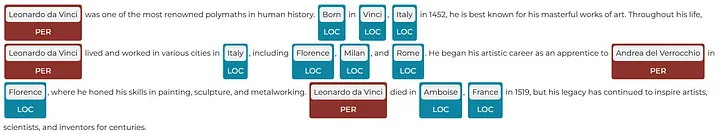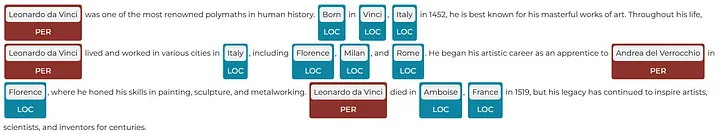

The document is again saved as an html file and similar to the above case, it is possible to change colors and filter the results.

Let’s filter for “PER” entity first and then display only the “LOC” entities:

In [12]:
visualiser.display(ppres, label_col='entities', document_col='document',
                   labels=['PER'])

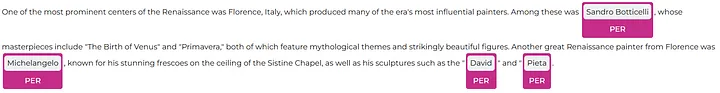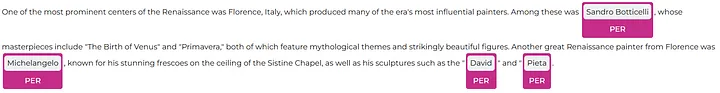

In [13]:
visualiser.display(ppres, label_col='entities', document_col='document',
                   labels=['LOC'])

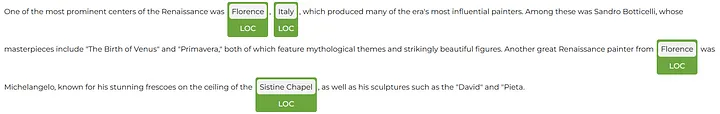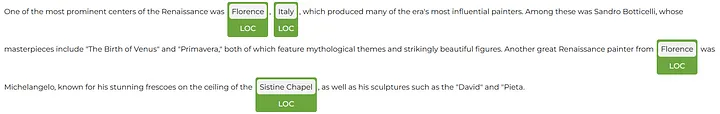

For additional information, please consult the following references:

- Documentation : [Spark NLP Display](https://nlp.johnsnowlabs.com/docs/en/display)
- For extended examples of usage, see the [Spark NLP repository](https://github.com/JohnSnowLabs/spark-nlp-display).

### Conclusion
In this article, we tried to get you familiar with the basics of ```NerVisualizer``` of Spark NLP Display, which is an open-source python [library](https://nlp.johnsnowlabs.com/docs/en/display) for visualizing the annotations, developed and maintained by [John Snow Labs](https://www.johnsnowlabs.com/).

NER visualization can be useful for a variety of applications. It can help analysts and researchers to understand the distribution and relationships of named entities in a text and to identify patterns or anomalies in the data. Also, it will be possible to gain insights from text data and to develop more accurate and effective NLP models.